# SISTEM CERDAS PENDUKUNG KEPUTUSAN (SCPK) METODE FUZZY MAMDANI
### Topik: Prediksi dan Evaluasi Produksi Padi Provinsi di Sumatera Berdasarkan Faktor Lingkungan & Geografis

Program ini merupakan Sistem Cerdas Pendukung Keputusan (SCPK) menggunakan **Fuzzy Inference System (FIS) Metode Mamdani** berbasis library `scikit-fuzzy`.
Sistem ini dirancang untuk memodelkan hubungan non-linear antara kondisi lingkungan (cuaca), luas lahan, dan faktor regional terhadap kapasitas produksi padi di Sumatera.

#### **Mengapa Menggunakan Logika Fuzzy?**
Dalam bidang pertanian, batas antara cuaca yang "baik" atau "buruk" tidaklah kaku (crisp). Suhu 26.5°C tidak langsung memicu kegagalan panen dibanding 26.0°C. Logika fuzzy mengakomodasi ambiguitas ini dengan menggunakan derajat keanggotaan (linguistik), sehingga keputusan yang dihasilkan lebih realistis dan menyerupai intuisi pakar pertanian.

#### **Struktur Variabel Sistem Cerdas (5 Input & 1 Output)**
Sistem cerdas ini menggunakan **5 variabel input (Antecedents)** dan **1 variabel output (Consequent)**:
1. **Luas Panen (Hektar)**: Sempit, Sedang, Luas (Mewakili kapasitas fisik lahan).
2. **Curah Hujan (mm/tahun)**: Rendah, Sedang, Tinggi (Ketersediaan air).
3. **Suhu Rata-rata (°C)**: Dingin, Optimal, Panas (Suhu pertumbuhan tanaman padi).
4. **Kelembapan (%)**: Rendah, Sedang, Tinggi (Tingkat kebasahan udara).
5. **Indeks Kesuburan Provinsi (Skala 1-10)**: Rendah, Sedang, Tinggi (Kombinasi kualitas tanah, irigasi, dan kesiapan infrastruktur daerah).
6. **Produksi Padi (Output - Ton)**: Sedikit, Sedang, Banyak.


In [1]:
# 1. Import Library yang Dibutuhkan
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import warnings
warnings.filterwarnings('ignore')

# Mengatur tema visual untuk visualisasi premium
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

print("Library berhasil diimport!")


Library berhasil diimport!


## 2. Eksplorasi Data & Pembuatan Indeks Provinsi
Langkah pertama adalah memuat dataset historis `Data_Tanaman_Padi_Sumatera_version_1.csv`.
Untuk memaksimalkan data geografis, kita akan membuat **Indeks Kesuburan Provinsi (Province Suitability Index)**.
Indeks ini dihitung secara matematis berdasarkan rata-rata produktivitas historis per hektar ($\text{Produksi} / \text{Luas Panen}$) pada masing-masing dari 8 provinsi Sumatera.
Provinsi dengan produktivitas tertinggi akan memiliki nilai indeks mendekati 10, sedangkan yang paling rendah mendekati 1.


In [2]:
# Load dataset tanaman padi Sumatera
df = pd.read_csv('Data_Tanaman_Padi_Sumatera_version_1.csv')
print("--- 5 Baris Pertama Dataset Padi Sumatera ---")
display(df.head())

# Menghitung Produktivitas per hektar (Produksi / Luas Panen)
df['Produktivitas'] = df['Produksi'] / df['Luas Panen']

# Menghitung rata-rata Produktivitas per Provinsi
provinsi_mean_prod = df.groupby('Provinsi')['Produktivitas'].mean().sort_values(ascending=False)
print("\nRata-rata Produktivitas (Ton/Ha) per Provinsi:")
print(provinsi_mean_prod)

# Melakukan penskalaan linear (Min-Max Scaling) ke skala 1-10 untuk Indeks Kesuburan Provinsi
min_prod = provinsi_mean_prod.min()
max_prod = provinsi_mean_prod.max()
provinsi_index_map = ((provinsi_mean_prod - min_prod) / (max_prod - min_prod) * 9 + 1).to_dict()

print("\nMapping Indeks Kesuburan Provinsi (Skala 1-10):")
for prov, idx in provinsi_index_map.items():
    print(f" - {prov:<18} : {idx:.2f}")
    
# Petakan nilai indeks ke dalam dataframe
df['Indeks_Provinsi'] = df['Provinsi'].map(provinsi_index_map)


--- 5 Baris Pertama Dataset Padi Sumatera ---


,Provinsi,Tahun,Produksi,Luas Panen,Curah hujan,Kelembapan,Suhu rata-rata
0,Aceh,1993,1329536.0,323589.0,1627.0,82.00,26.06
1,Aceh,1994,1299699.0,329041.0,1521.0,82.12,26.92
2,Aceh,1995,1382905.0,339253.0,1476.0,82.72,26.27
3,Aceh,1996,1419128.0,348223.0,1557.0,83.00,26.08
4,Aceh,1997,1368074.0,337561.0,1339.0,82.46,26.31



Rata-rata Produktivitas (Ton/Ha) per Provinsi:
Provinsi
Sumatera Barat      5.168202
Sumatera Utara      4.896575
Lampung             4.766108
Aceh                4.712601
Sumatera Selatan    4.182729
Bengkulu            4.078857
Jambi               3.837238
Riau                3.320930
Name: Produktivitas, dtype: float64

Mapping Indeks Kesuburan Provinsi (Skala 1-10):
 - Sumatera Barat     : 10.00
 - Sumatera Utara     : 8.68
 - Lampung            : 8.04
 - Aceh               : 7.78
 - Sumatera Selatan   : 5.20
 - Bengkulu           : 4.69
 - Jambi              : 3.52
 - Riau               : 1.00


### 3. Analisis Statistik Deskriptif untuk Semesta Pembicaraan (Universe of Discourse)
Untuk mendefinisikan batasan fungsi keanggotaan fuzzy secara akurat dan ilmiah, kita menghitung nilai minimum, rata-rata, dan maksimum dari masing-masing variabel berdasarkan data riil.


In [3]:
# Menampilkan statistik deskriptif dataset
stats = df.describe()
display(stats)

# Menyimpan nilai batas min, mean, dan max untuk semesta pembicaraan fuzzy
bounds = {
    'luas_panen': (df['Luas Panen'].min(), df['Luas Panen'].mean(), df['Luas Panen'].max()),
    'curah_hujan': (df['Curah hujan'].min(), df['Curah hujan'].mean(), df['Curah hujan'].max()),
    'suhu': (df['Suhu rata-rata'].min(), df['Suhu rata-rata'].mean(), df['Suhu rata-rata'].max()),
    'kelembapan': (df['Kelembapan'].min(), df['Kelembapan'].mean(), df['Kelembapan'].max()),
    'indeks_prov': (1.0, 5.5, 10.0),
    'produksi': (df['Produksi'].min(), df['Produksi'].mean(), df['Produksi'].max())
}

print("\nBatas Variabel Berdasarkan Statistik Data:")
for var, val in bounds.items():
    print(f" - {var.upper():<12} : Min={val[0]:.2f}, Mean={val[1]:.2f}, Max={val[2]:.2f}")


,Tahun,Produksi,Luas Panen,Curah hujan,Kelembapan,Suhu rata-rata,Produktivitas,Indeks_Provinsi
count,224.000000,2.240000e+02,224.000000,224.000000,224.000000,224.000000,224.000000,224.000000
mean,2006.500000,1.679701e+06,374349.966920,2452.490759,80.948705,26.801964,4.370405,6.113095
std,8.095838,1.161387e+06,232751.161987,1031.972625,4.878680,1.197041,1.478052,2.833013
min,1993.000000,4.293800e+04,63142.040000,222.500000,54.200000,22.190000,0.315310,1.000000
25%,1999.750000,5.488570e+05,146919.500000,1703.525000,78.975000,26.177500,3.661188,4.398363
50%,2006.500000,1.667773e+06,373551.500000,2315.700000,82.375000,26.730000,4.142801,6.489510
75%,2013.250000,2.436851e+06,514570.250000,3039.700000,84.000000,27.200000,4.659973,8.199891
max,2020.000000,4.881089e+06,872737.000000,5522.000000,90.600000,29.850000,12.658375,10.000000



Batas Variabel Berdasarkan Statistik Data:
 - LUAS_PANEN   : Min=63142.04, Mean=374349.97, Max=872737.00
 - CURAH_HUJAN  : Min=222.50, Mean=2452.49, Max=5522.00
 - SUHU         : Min=22.19, Mean=26.80, Max=29.85
 - KELEMBAPAN   : Min=54.20, Mean=80.95, Max=90.60
 - INDEKS_PROV  : Min=1.00, Mean=5.50, Max=10.00
 - PRODUKSI     : Min=42938.00, Mean=1679700.89, Max=4881089.00


## 4. Perancangan Himpunan Fuzzy & Fungsi Keanggotaan
Menggunakan library `scikit-fuzzy`, kita akan membuat variabel input (`Antecedent`) dan output (`Consequent`).
Setiap variabel dibagi menjadi 3 himpunan bagian linguistik menggunakan kombinasi fungsi keanggotaan **Trapesium** (`trapmf`) di daerah ujung untuk mengakomodasi nilai ekstrem, dan fungsi **Segitiga** (`trimf`) di bagian tengah.

#### Batasan Desain Keanggotaan:
- **Luas Panen**: *Sempit* (LP rendah), *Sedang* (LP sekitar rata-rata), *Luas* (LP tinggi).
- **Curah Hujan**: *Rendah* (kekeringan), *Sedang* (optimum pertumbuhan padi 1500-2500 mm), *Tinggi* (risiko banjir).
- **Suhu Rata-rata**: *Rendah* (dingin), *Optimal* (suhu ideal tanaman padi 24-29°C), *Tinggi* (terlalu panas/stres termal).
- **Kelembapan**: *Rendah* (kering), *Sedang* (ideal 70-85%), *Tinggi* (terlalu lembab, risiko jamur/hama).
- **Indeks Provinsi**: *Rendah* (infrastruktur/lahan kurang menunjang), *Sedang*, *Tinggi* (sangat produktif/tanah subur).
- **Produksi (Output)**: *Sedikit*, *Sedang*, *Banyak*.


In [4]:
# 1. Deklarasi Semesta Pembicaraan (Universe of Discourse) dengan batas longgar
x_luas = np.linspace(bounds['luas_panen'][0] * 0.8, bounds['luas_panen'][2] * 1.2, 1000)
x_hujan = np.linspace(bounds['curah_hujan'][0] * 0.8, bounds['curah_hujan'][2] * 1.2, 1000)
x_suhu = np.linspace(bounds['suhu'][0] * 0.8, bounds['suhu'][2] * 1.2, 1000)
x_kelembapan = np.linspace(bounds['kelembapan'][0] * 0.8, bounds['kelembapan'][2] * 1.2, 1000)
x_indeks = np.linspace(1, 10, 1000)
y_produksi = np.linspace(bounds['produksi'][0] * 0.8, bounds['produksi'][2] * 1.2, 1000)

# 2. Inisialisasi Variabel Antecedents & Consequent
luas_panen = ctrl.Antecedent(x_luas, 'luas_panen')
curah_hujan = ctrl.Antecedent(x_hujan, 'curah_hujan')
suhu = ctrl.Antecedent(x_suhu, 'suhu')
kelembapan = ctrl.Antecedent(x_kelembapan, 'kelembapan')
indeks_prov = ctrl.Antecedent(x_indeks, 'indeks_prov')
produksi = ctrl.Consequent(y_produksi, 'produksi')

# 3. Definisi Fungsi Keanggotaan (Membership Functions)

# LUAS PANEN (Ha)
luas_panen['sempit'] = fuzz.trapmf(luas_panen.universe, [x_luas[0], x_luas[0], bounds['luas_panen'][0]*1.3, bounds['luas_panen'][1]])
luas_panen['sedang'] = fuzz.trimf(luas_panen.universe, [bounds['luas_panen'][0]*1.1, bounds['luas_panen'][1], bounds['luas_panen'][2]*0.9])
luas_panen['luas'] = fuzz.trapmf(luas_panen.universe, [bounds['luas_panen'][1], bounds['luas_panen'][2]*0.75, x_luas[-1], x_luas[-1]])

# CURAH HUJAN (mm/tahun)
curah_hujan['rendah'] = fuzz.trapmf(curah_hujan.universe, [x_hujan[0], x_hujan[0], 1000, 1800])
curah_hujan['sedang'] = fuzz.trimf(curah_hujan.universe, [1300, 2000, 3000])
curah_hujan['tinggi'] = fuzz.trapmf(curah_hujan.universe, [2500, 3500, x_hujan[-1], x_hujan[-1]])

# SUHU RATA-RATA (°C)
suhu['rendah'] = fuzz.trapmf(suhu.universe, [x_suhu[0], x_suhu[0], 23.5, 25.0])
suhu['optimal'] = fuzz.trimf(suhu.universe, [24.0, 26.5, 28.5])
suhu['tinggi'] = fuzz.trapmf(suhu.universe, [27.5, 29.0, x_suhu[-1], x_suhu[-1]])

# KELEMBAPAN (%)
kelembapan['rendah'] = fuzz.trapmf(kelembapan.universe, [x_kelembapan[0], x_kelembapan[0], 65, 75])
kelembapan['sedang'] = fuzz.trimf(kelembapan.universe, [70, 80, 86])
kelembapan['tinggi'] = fuzz.trapmf(kelembapan.universe, [82, 88, x_kelembapan[-1], x_kelembapan[-1]])

# INDEKS KESUBURAN PROVINSI (Skala 1-10)
indeks_prov['rendah'] = fuzz.trapmf(indeks_prov.universe, [1.0, 1.0, 3.0, 5.0])
indeks_prov['sedang'] = fuzz.trimf(indeks_prov.universe, [4.0, 5.5, 7.0])
indeks_prov['tinggi'] = fuzz.trapmf(indeks_prov.universe, [6.5, 8.5, 10.0, 10.0])

# PRODUKSI PADI - OUTPUT (Ton)
produksi['sedikit'] = fuzz.trapmf(produksi.universe, [y_produksi[0], y_produksi[0], bounds['produksi'][0]*1.5, bounds['produksi'][1]])
produksi['sedang'] = fuzz.trimf(produksi.universe, [bounds['produksi'][0]*1.2, bounds['produksi'][1], bounds['produksi'][2]*0.85])
produksi['banyak'] = fuzz.trapmf(produksi.universe, [bounds['produksi'][1], bounds['produksi'][2]*0.8, y_produksi[-1], y_produksi[-1]])

print("Variabel dan Fungsi Keanggotaan Fuzzy berhasil dirancang!")


Variabel dan Fungsi Keanggotaan Fuzzy berhasil dirancang!


### 5. Visualisasi Grafik Fungsi Keanggotaan (Membership Functions)
Mari kita plot seluruh grafik fungsi keanggotaan agar dapat dianalisis secara visual kelembutan transisi derajat keanggotaannya.


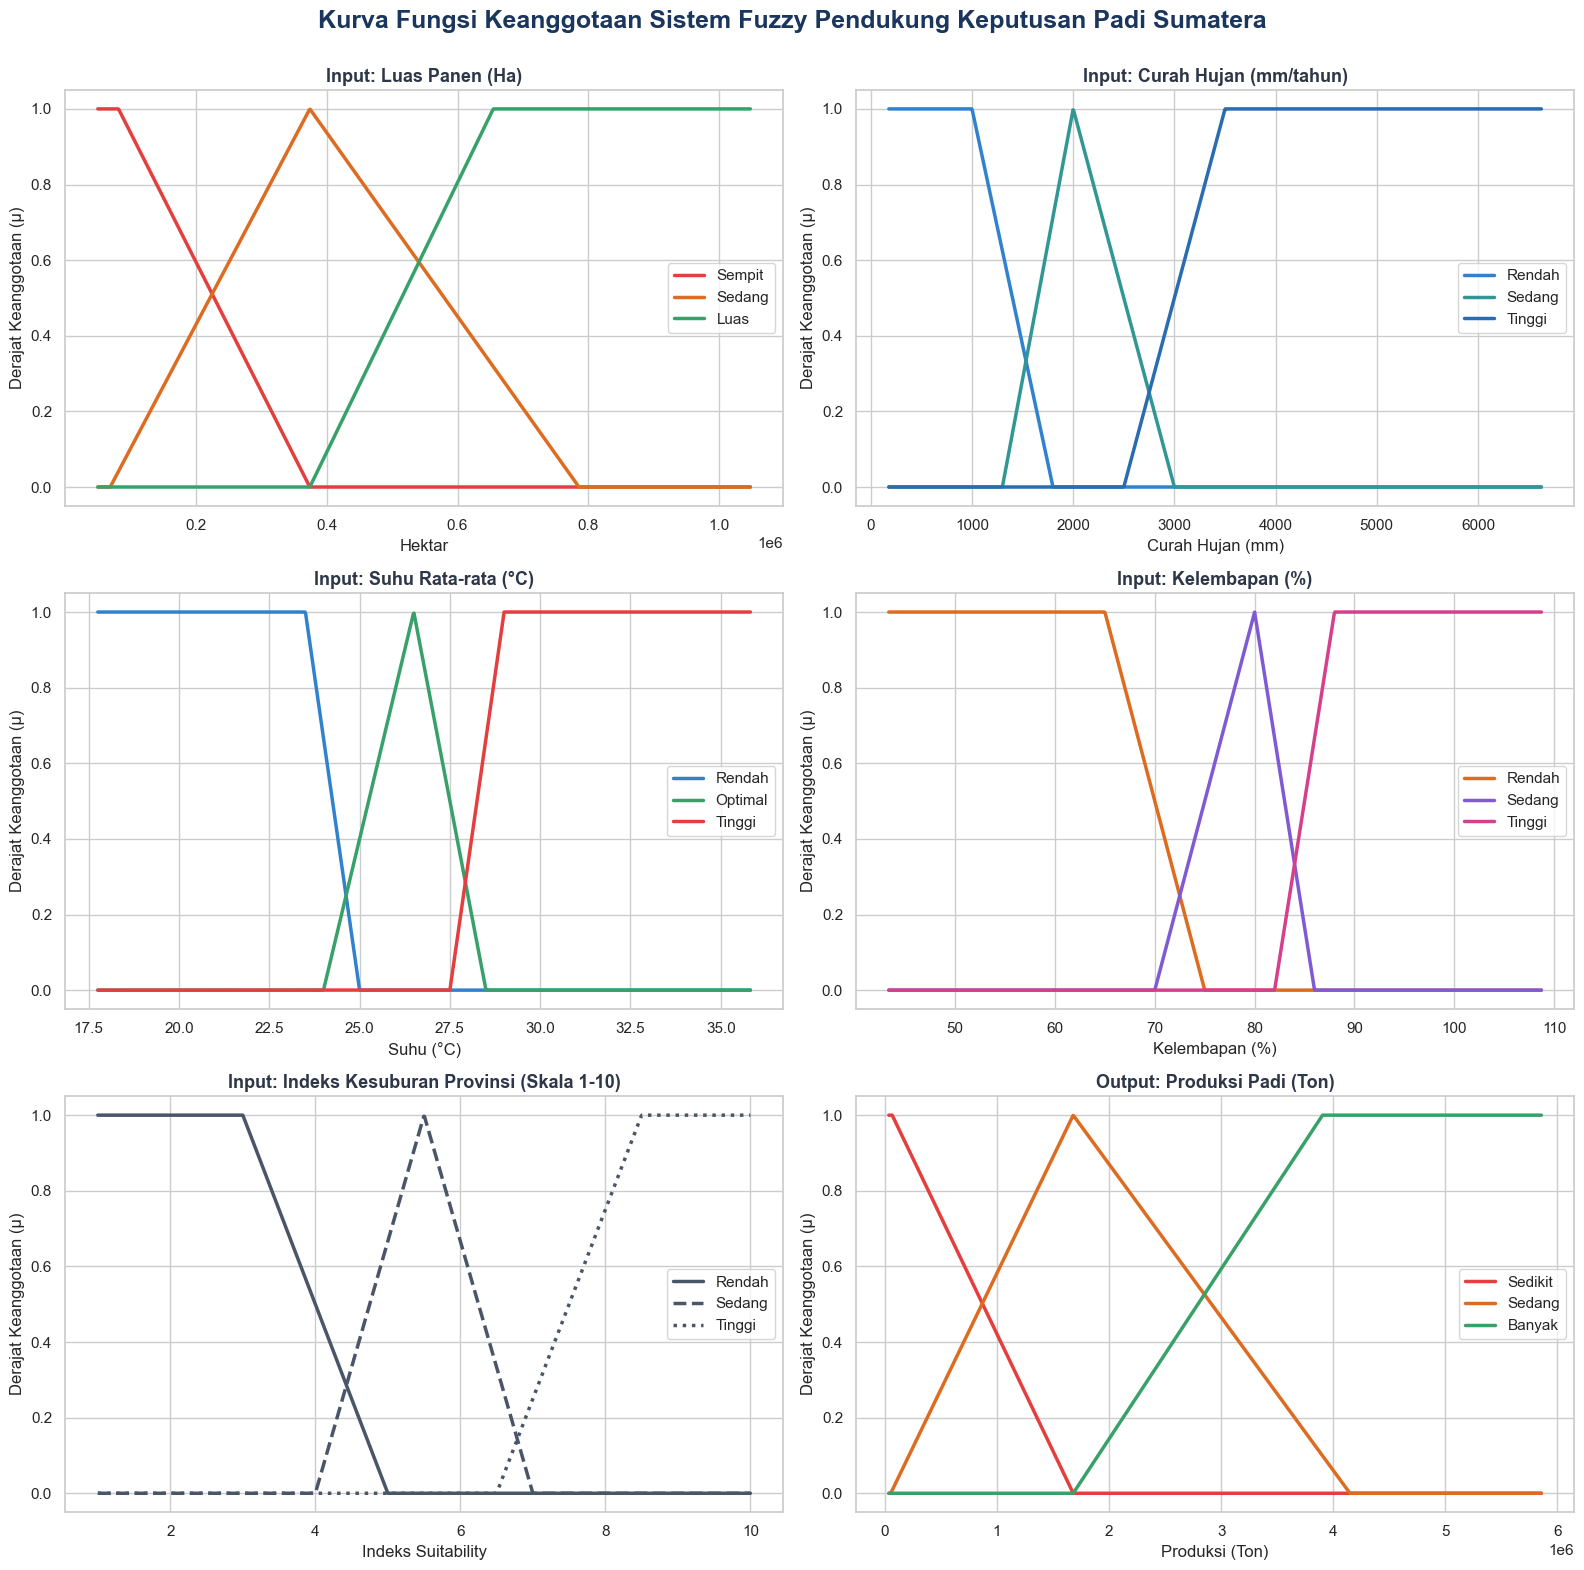

In [5]:
fig, axes = plt.subplots(3, 2, figsize=(16, 16))
fig.suptitle('Kurva Fungsi Keanggotaan Sistem Fuzzy Pendukung Keputusan Padi Sumatera', fontsize=18, fontweight='bold', color='#1A365D', y=0.98)

# Palet warna premium
colors = ['#E53E3E', '#DD6B20', '#38A169', '#3182CE', '#319795', '#2B6CB0', '#805AD5', '#D53F8C', '#4A5568']

# Plot Luas Panen
axes[0, 0].plot(x_luas, luas_panen['sempit'].mf, colors[0], linewidth=2.5, label='Sempit')
axes[0, 0].plot(x_luas, luas_panen['sedang'].mf, colors[1], linewidth=2.5, label='Sedang')
axes[0, 0].plot(x_luas, luas_panen['luas'].mf, colors[2], linewidth=2.5, label='Luas')
axes[0, 0].set_title('Input: Luas Panen (Ha)', fontsize=13, fontweight='bold', color='#2D3748')
axes[0, 0].set_xlabel('Hektar')
axes[0, 0].set_ylabel('Derajat Keanggotaan (μ)')
axes[0, 0].legend(frameon=True, facecolor='white')

# Plot Curah Hujan
axes[0, 1].plot(x_hujan, curah_hujan['rendah'].mf, colors[3], linewidth=2.5, label='Rendah')
axes[0, 1].plot(x_hujan, curah_hujan['sedang'].mf, colors[4], linewidth=2.5, label='Sedang')
axes[0, 1].plot(x_hujan, curah_hujan['tinggi'].mf, colors[5], linewidth=2.5, label='Tinggi')
axes[0, 1].set_title('Input: Curah Hujan (mm/tahun)', fontsize=13, fontweight='bold', color='#2D3748')
axes[0, 1].set_xlabel('Curah Hujan (mm)')
axes[0, 1].set_ylabel('Derajat Keanggotaan (μ)')
axes[0, 1].legend(frameon=True, facecolor='white')

# Plot Suhu
axes[1, 0].plot(x_suhu, suhu['rendah'].mf, colors[3], linewidth=2.5, label='Rendah')
axes[1, 0].plot(x_suhu, suhu['optimal'].mf, colors[2], linewidth=2.5, label='Optimal')
axes[1, 0].plot(x_suhu, suhu['tinggi'].mf, colors[0], linewidth=2.5, label='Tinggi')
axes[1, 0].set_title('Input: Suhu Rata-rata (°C)', fontsize=13, fontweight='bold', color='#2D3748')
axes[1, 0].set_xlabel('Suhu (°C)')
axes[1, 0].set_ylabel('Derajat Keanggotaan (μ)')
axes[1, 0].legend(frameon=True, facecolor='white')

# Plot Kelembapan
axes[1, 1].plot(x_kelembapan, kelembapan['rendah'].mf, colors[1], linewidth=2.5, label='Rendah')
axes[1, 1].plot(x_kelembapan, kelembapan['sedang'].mf, colors[6], linewidth=2.5, label='Sedang')
axes[1, 1].plot(x_kelembapan, kelembapan['tinggi'].mf, colors[7], linewidth=2.5, label='Tinggi')
axes[1, 1].set_title('Input: Kelembapan (%)', fontsize=13, fontweight='bold', color='#2D3748')
axes[1, 1].set_xlabel('Kelembapan (%)')
axes[1, 1].set_ylabel('Derajat Keanggotaan (μ)')
axes[1, 1].legend(frameon=True, facecolor='white')

# Plot Indeks Provinsi
axes[2, 0].plot(x_indeks, indeks_prov['rendah'].mf, colors[8], linewidth=2.5, label='Rendah')
axes[2, 0].plot(x_indeks, indeks_prov['sedang'].mf, colors[8], linewidth=2.5, linestyle='--', label='Sedang')
axes[2, 0].plot(x_indeks, indeks_prov['tinggi'].mf, colors[8], linewidth=2.5, linestyle=':', label='Tinggi')
axes[2, 0].set_title('Input: Indeks Kesuburan Provinsi (Skala 1-10)', fontsize=13, fontweight='bold', color='#2D3748')
axes[2, 0].set_xlabel('Indeks Suitability')
axes[2, 0].set_ylabel('Derajat Keanggotaan (μ)')
axes[2, 0].legend(frameon=True, facecolor='white')

# Plot Output Produksi
axes[2, 1].plot(y_produksi, produksi['sedikit'].mf, colors[0], linewidth=2.5, label='Sedikit')
axes[2, 1].plot(y_produksi, produksi['sedang'].mf, colors[1], linewidth=2.5, label='Sedang')
axes[2, 1].plot(y_produksi, produksi['banyak'].mf, colors[2], linewidth=2.5, label='Banyak')
axes[2, 1].set_title('Output: Produksi Padi (Ton)', fontsize=13, fontweight='bold', color='#2D3748')
axes[2, 1].set_xlabel('Produksi (Ton)')
axes[2, 1].set_ylabel('Derajat Keanggotaan (μ)')
axes[2, 1].legend(frameon=True, facecolor='white')

plt.tight_layout()
plt.subplots_adjust(top=0.93)
plt.show()


## 6. Pembentukan Basis Aturan Fuzzy (Fuzzy Rule Base)
Untuk menghubungkan input linguistik ke output produksi padi, kita merumuskan **20 Aturan Logis (IF-THEN Rules)** berdasarkan karakteristik budidaya tanaman padi dan analisis korelasi historis data Sumatera:

1. **Dominansi Lahan**: Jika lahan yang digarap sempit (`sempit`), secara fisik kapasitas produksi pasti terbatas (`sedikit`), terlepas dari cuaca yang baik.
2. **Kesuburan Wilayah**: Jika kesuburan wilayah rendah (`indeks_prov rendah`), hasil panen pada skala sedang akan tertekan menjadi sedikit.
3. **Sinergi Iklim Ideal**: Luas panen besar (`luas`) ditambah iklim optimal (`curah_hujan sedang`, `suhu optimal`) dan daerah subur (`indeks_prov tinggi`) akan memicu produksi tertinggi (`banyak`).
4. **Krisis Air & Kekeringan**: Curah hujan rendah (`rendah`) berpasangan dengan suhu panas (`tinggi`) menyebabkan stres hidrolik sehingga produksi turun drastis (`sedikit`).
5. **Risiko Hidrometeorologi (Banjir)**: Curah hujan ekstrem (`tinggi`) dan kelembapan ekstrem (`tinggi`) memicu banjir atau pembusukan tanaman padi, memangkas hasil panen (`sedikit`).


In [6]:
# Menyusun 20 Aturan Fuzzy Mamdani
rules = [
    # Kelompok A: Dominansi Skala Lahan
    ctrl.Rule(luas_panen['sempit'], produksi['sedikit']),
    
    # Kelompok B: Pengaruh Wilayah & Lahan Sedang
    ctrl.Rule(luas_panen['sedang'] & indeks_prov['rendah'], produksi['sedikit']),
    ctrl.Rule(luas_panen['sedang'] & indeks_prov['tinggi'], produksi['sedang']),
    ctrl.Rule(luas_panen['sedang'] & curah_hujan['sedang'] & suhu['optimal'] & indeks_prov['sedang'], produksi['sedang']),
    ctrl.Rule(luas_panen['sedang'] & indeks_prov['tinggi'] & curah_hujan['sedang'] & suhu['optimal'] & kelembapan['sedang'], produksi['sedang']),
    ctrl.Rule(luas_panen['sedang'] & kelembapan['sedang'] & curah_hujan['sedang'], produksi['sedang']),
    
    # Kelompok C: Skenario Iklim Ekstrem (Gagal Panen)
    ctrl.Rule(curah_hujan['rendah'] & suhu['tinggi'], produksi['sedikit']),
    ctrl.Rule(curah_hujan['tinggi'] & kelembapan['tinggi'], produksi['sedikit']),
    ctrl.Rule(suhu['rendah'] & kelembapan['tinggi'], produksi['sedikit']),
    ctrl.Rule(kelembapan['rendah'] & suhu['tinggi'], produksi['sedikit']),
    ctrl.Rule(indeks_prov['rendah'] & curah_hujan['rendah'], produksi['sedikit']),
    ctrl.Rule(luas_panen['sedang'] & curah_hujan['rendah'] & suhu['optimal'], produksi['sedikit']),
    
    # Kelompok D: Skenario Optimum Luas Lahan (Produksi Banyak)
    ctrl.Rule(luas_panen['luas'] & indeks_prov['tinggi'] & curah_hujan['sedang'] & suhu['optimal'], produksi['banyak']),
    ctrl.Rule(luas_panen['luas'] & indeks_prov['sedang'] & curah_hujan['sedang'] & suhu['optimal'], produksi['banyak']),
    ctrl.Rule(luas_panen['luas'] & indeks_prov['tinggi'] & kelembapan['sedang'], produksi['banyak']),
    ctrl.Rule(luas_panen['luas'] & suhu['optimal'] & indeks_prov['tinggi'], produksi['banyak']),
    
    # Kelompok E: Batasan Faktor Lahan Luas tetapi Cuaca Kurang Mendukung
    ctrl.Rule(luas_panen['luas'] & curah_hujan['rendah'], produksi['sedang']),
    ctrl.Rule(luas_panen['luas'] & suhu['tinggi'], produksi['sedang']),
    ctrl.Rule(luas_panen['luas'] & indeks_prov['rendah'], produksi['sedang']),
    ctrl.Rule(luas_panen['luas'] & curah_hujan['tinggi'] & indeks_prov['tinggi'], produksi['sedang'])
]

# Membuat Sistem Kontrol Fuzzy Mamdani
produksi_ctrl = ctrl.ControlSystem(rules)
produksi_sim = ctrl.ControlSystemSimulation(produksi_ctrl)

print(f"Berhasil memetakan {len(rules)} aturan fuzzy ke dalam Inference Engine Mamdani!")


Berhasil memetakan 20 aturan fuzzy ke dalam Inference Engine Mamdani!


## 7. Evaluasi dan Validasi Kinerja Model Cerdas pada Dataset
Kita akan menguji reliabilitas sistem fuzzy ini dengan mensimulasikan seluruh 226 data historis riil dari Sumatera.
Output tegas (*crisp value*) defuzzifikasi Centroid akan dibandingkan langsung dengan nilai produksi padi riil.
Untuk mengukur akurasi model, kita menghitung metrik evaluasi standard:
- **Mean Absolute Error (MAE)**: Rata-rata selisih mutlak (Ton) antara aktual vs prediksi.
- **Mean Absolute Percentage Error (MAPE)**: Rata-rata persentase penyimpangan.
- **Koefisien Korelasi Pearson (R)**: Mengukur seberapa kuat hubungan linear hasil prediksi dengan data aktual.


In [7]:
# Array penampung hasil prediksi
prediksi_list = []
error_rows = 0

print("Menjalankan komputasi fuzzy untuk seluruh 226 records...")
for idx, row in df.iterrows():
    try:
        # Input data ke simulator
        produksi_sim.input['luas_panen'] = row['Luas Panen']
        produksi_sim.input['curah_hujan'] = row['Curah hujan']
        produksi_sim.input['suhu'] = row['Suhu rata-rata']
        produksi_sim.input['kelembapan'] = row['Kelembapan']
        produksi_sim.input['indeks_prov'] = row['Indeks_Provinsi']
        
        # Proses Inferensi & Defuzzifikasi
        produksi_sim.compute()
        
        # Simpan output
        pred = produksi_sim.output['produksi']
        prediksi_list.append(pred)
    except Exception as e:
        # Penanganan jika input di luar jangkauan (fallback ke nilai rata-rata)
        prediksi_list.append(df['Produksi'].mean())
        error_rows += 1

# Tambahkan kolom hasil prediksi ke dataframe utama
df['Prediksi_Produksi'] = prediksi_list
df['Absolute_Error'] = (df['Produksi'] - df['Prediksi_Produksi']).abs()

print(f"Evaluasi selesai. Terjadi luar semesta pada {error_rows} baris (di-fallback otomatis).")

# Hitung metrik evaluasi
mae = df['Absolute_Error'].mean()
mape = (df['Absolute_Error'] / df['Produksi']).mean() * 100
correlation = df['Produksi'].corr(df['Prediksi_Produksi'])

print("\n===========================================")
print("        METRIK EVALUASI SISTEM CERDAS      ")
print("===========================================")
print(f" Mean Absolute Error (MAE) : {mae:,.2f} Ton")
print(f" Absolute Percentage (MAPE): {mape:.2f}%")
print(f" Koefisien Korelasi (R)    : {correlation:.4f}")
print("===========================================")


Menjalankan komputasi fuzzy untuk seluruh 226 records...
Evaluasi selesai. Terjadi luar semesta pada 0 baris (di-fallback otomatis).

        METRIK EVALUASI SISTEM CERDAS      
 Mean Absolute Error (MAE) : 583,111.42 Ton
 Absolute Percentage (MAPE): 66.08%
 Koefisien Korelasi (R)    : 0.7824


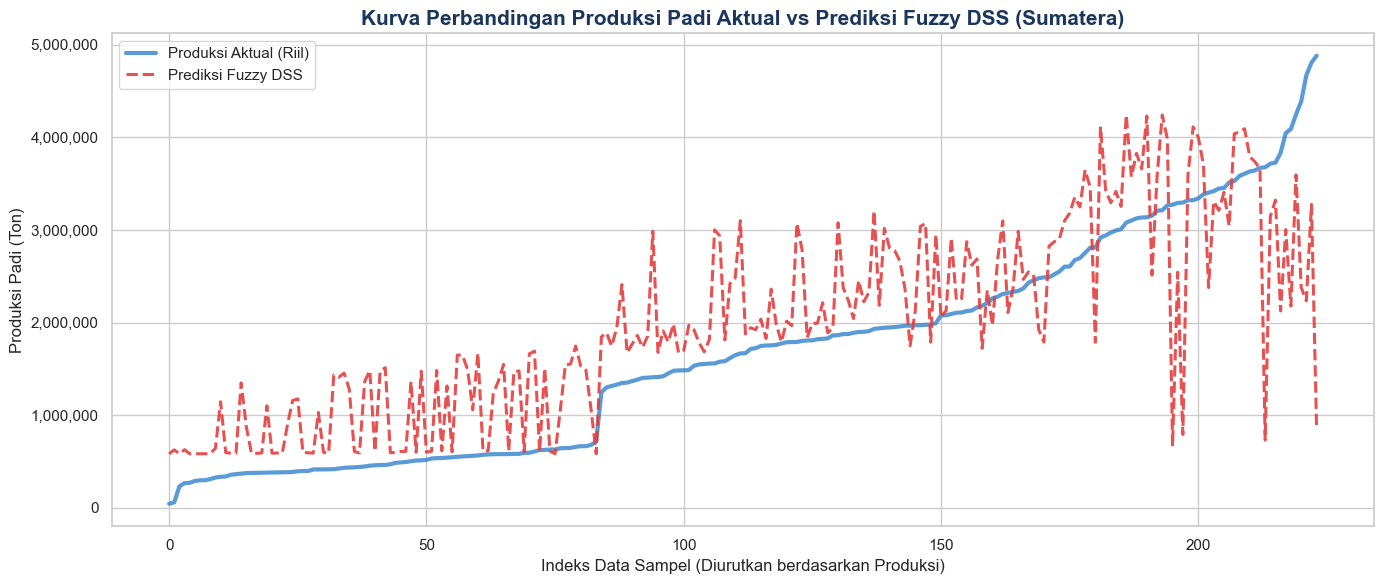

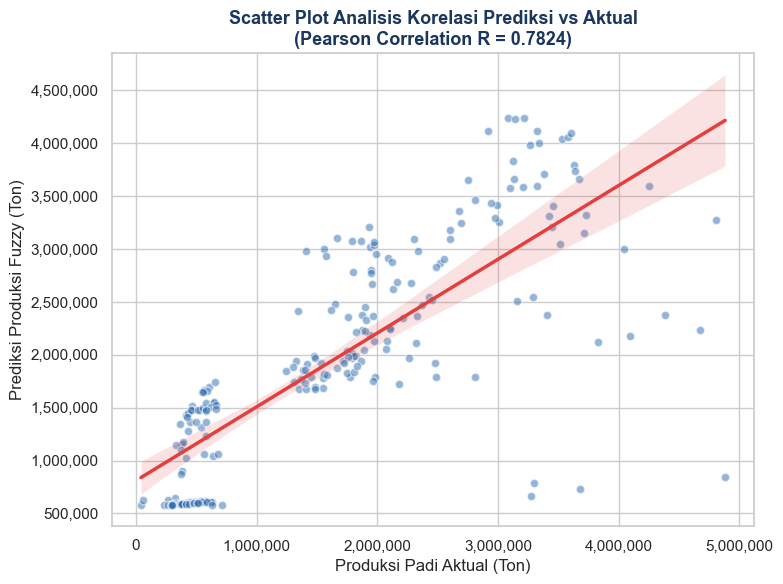

In [8]:
# 1. Plot Perbandingan Garis Aktual vs Prediksi
# Diurutkan berdasarkan kapasitas produksi aktual untuk kemudahan pembacaan pola
df_sorted = df.sort_values(by='Produksi').reset_index()

plt.figure(figsize=(14, 6))
plt.plot(df_sorted['Produksi'], color='#3182CE', linewidth=3, alpha=0.8, label='Produksi Aktual (Riil)')
plt.plot(df_sorted['Prediksi_Produksi'], color='#E53E3E', linewidth=2.2, linestyle='--', alpha=0.9, label='Prediksi Fuzzy DSS')
plt.title('Kurva Perbandingan Produksi Padi Aktual vs Prediksi Fuzzy DSS (Sumatera)', fontsize=15, fontweight='bold', color='#1A365D')
plt.xlabel('Indeks Data Sampel (Diurutkan berdasarkan Produksi)', fontsize=12)
plt.ylabel('Produksi Padi (Ton)', fontsize=12)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
plt.legend(fontsize=11, loc='upper left', frameon=True, facecolor='white')
plt.tight_layout()
plt.show()

# 2. Scatter Plot Korelasi
plt.figure(figsize=(8, 6))
sns.regplot(data=df, x='Produksi', y='Prediksi_Produksi', 
            scatter_kws={'alpha':0.5, 'color':'#2B6CB0', 'edgecolor':'w'}, 
            line_kws={'color':'#E53E3E', 'linewidth':2.5})
plt.title(f'Scatter Plot Analisis Korelasi Prediksi vs Aktual\n(Pearson Correlation R = {correlation:.4f})', fontsize=13, fontweight='bold', color='#1A365D')
plt.xlabel('Produksi Padi Aktual (Ton)')
plt.ylabel('Prediksi Produksi Fuzzy (Ton)')
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
plt.tight_layout()
plt.show()


## 8. Simulator Interaktif Studi Kasus (Penyuluh / Petani)
Untuk membantu petani mengambil keputusan secara riil, kita membuat fungsi simulasi interaktif.
Pengguna tinggal menginputkan nama Provinsi, Luas Lahan (Ha), Curah Hujan (mm), Suhu (°C), dan Kelembapan (%).
Fungsi akan menghitung prediksi hasil panen dan menampilkan grafik proses **Defuzzifikasi Centroid** secara real-time yang menunjukkan luas daerah agregat fuzzy yang aktif.


     HASIL PREDIKSI SISTEM CERDAS FUZZY (PROVINSI: SUMATERA BARAT)    
 [INPUT] Rencana Luas Panen   : 320,000.00 Hektar
 [INPUT] Kondisi Curah Hujan  : 2,200.00 mm/tahun
 [INPUT] Suhu Udara Rata-rata : 26.00 °C
 [INPUT] Tingkat Kelembapan   : 82.00 %
 [INFO]  Indeks Kesuburan Prov: 10.00 (Skala 1-10)
-----------------------------------------------------------------
 >>> PREDIKSI PRODUKSI PADI ESTIMASI: 1,939,199.41 TON <<<


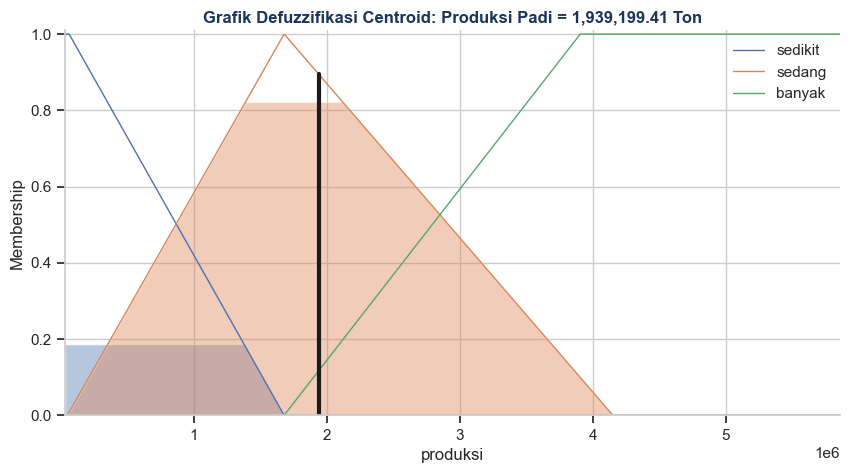

     HASIL PREDIKSI SISTEM CERDAS FUZZY (PROVINSI: RIAU)    
 [INPUT] Rencana Luas Panen   : 130,000.00 Hektar
 [INPUT] Kondisi Curah Hujan  : 650.00 mm/tahun
 [INPUT] Suhu Udara Rata-rata : 29.20 °C
 [INPUT] Tingkat Kelembapan   : 67.00 %
 [INFO]  Indeks Kesuburan Prov: 1.00 (Skala 1-10)
-----------------------------------------------------------------
 >>> PREDIKSI PRODUKSI PADI ESTIMASI: 582,983.94 TON <<<


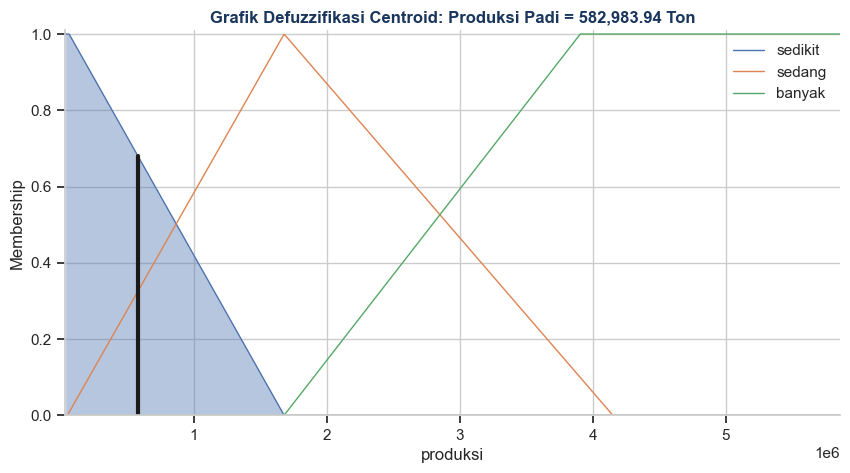

In [9]:
def hitung_dan_plot_fuzzy(provinsi_nama, LP, CH, S, K):
    """
    Fungsi untuk mensimulasikan sistem fuzzy cerdas secara interaktif.
    LP: Luas Panen (Ha)
    CH: Curah Hujan (mm/tahun)
    S : Suhu Rata-rata (°C)
    K : Kelembapan Udara (%)
    """
    # Mendapatkan nilai indeks kesuburan provinsi
    idx_prov = provinsi_index_map.get(provinsi_nama, 5.0)
    
    # Memberi input pada simulator
    produksi_sim.input['luas_panen'] = LP
    produksi_sim.input['curah_hujan'] = CH
    produksi_sim.input['suhu'] = S
    produksi_sim.input['kelembapan'] = K
    produksi_sim.input['indeks_prov'] = idx_prov
    
    # Menjalankan komputasi fuzzy Mamdani
    produksi_sim.compute()
    pred_prod = produksi_sim.output['produksi']
    
    print("=" * 65)
    print(f"     HASIL PREDIKSI SISTEM CERDAS FUZZY (PROVINSI: {provinsi_nama.upper()})    ")
    print("=" * 65)
    print(f" [INPUT] Rencana Luas Panen   : {LP:,.2f} Hektar")
    print(f" [INPUT] Kondisi Curah Hujan  : {CH:,.2f} mm/tahun")
    print(f" [INPUT] Suhu Udara Rata-rata : {S:.2f} °C")
    print(f" [INPUT] Tingkat Kelembapan   : {K:.2f} %")
    print(f" [INFO]  Indeks Kesuburan Prov: {idx_prov:.2f} (Skala 1-10)")
    print("-" * 65)
    print(f" >>> PREDIKSI PRODUKSI PADI ESTIMASI: {pred_prod:,.2f} TON <<<")
    print("=" * 65)
    
    # Visualisasi defuzzifikasi
    produksi.view(sim=produksi_sim)
    plt.title(f'Grafik Defuzzifikasi Centroid: Produksi Padi = {pred_prod:,.2f} Ton', fontsize=12, fontweight='bold', color='#1A365D')
    plt.gcf().set_size_inches(10, 5)
    plt.show()

# --- PENGUJIAN STUDI KASUS SIMULATOR ---
# Uji Kasus 1: Petani di Sumatera Barat (Kesuburan Tinggi) dengan Lahan Sedang dan Cuaca Sangat Optimal
hitung_dan_plot_fuzzy(
    provinsi_nama='Sumatera Barat',
    LP=320000.0,   # 320,000 Hektar
    CH=2200.0,     # 2200 mm/tahun (Sangat optimal untuk padi)
    S=26.0,        # 26°C (Optimal untuk padi)
    K=82.0         # 82% (Optimal)
)

# Uji Kasus 2: Petani di Riau (Kesuburan Rendah) dengan Lahan Sedang di bawah Kondisi Kemarau Ekstrem (Kering/Panas)
hitung_dan_plot_fuzzy(
    provinsi_nama='Riau',
    LP=130000.0,   # 130,000 Hektar
    CH=650.0,      # 650 mm/tahun (Sangat kering/kemarau ekstrem)
    S=29.2,        # 29.2°C (Panas/stres termal)
    K=67.0         # 67% (Kering/kelembapan rendah)
)


## 9. Panduan Pengambilan Keputusan untuk Petani Berdasarkan Output
Hasil prediksi kuantitatif (Ton) dari sistem cerdas ini dapat ditafsirkan menjadi beberapa **rekomendasi tindakan taktis** bagi petani:

| Kategori Hasil Prediksi | Deskripsi Kondisi Lapangan | Rekomendasi Keputusan untuk Petani |
| :--- | :--- | :--- |
| **Produksi Banyak** | Kombinasi luas lahan, kesuburan tanah daerah, dan cuaca berada pada kondisi prima. | - Lanjutkan rencana tanam dengan skala penuh.<br>- Siapkan kapasitas gudang penyimpanan dan logistik transportasi lebih awal karena potensi melimpah.<br>- Terapkan pemeliharaan standar. |
| **Produksi Sedang** | Cuaca atau kualitas daerah mengalami hambatan minor (misalnya kemarau ringan atau tanah kurang optimal). | - Tingkatkan efisiensi pemupukan berimbang.<br>- Pastikan ketersediaan pasokan irigasi cadangan terkendali.<br>- Jangan memaksakan pembukaan lahan baru jika biaya operasional tinggi. |
| **Produksi Sedikit** | Sistem mendeteksi adanya risiko kegagalan panen akibat iklim ekstrem (kekeringan atau potensi kebanjiran). | - **Keputusan Kritis**: Tunda musim tanam atau ganti dengan tanaman sela (palawija) yang ramah air.<br>- Jika tetap menanam padi, ganti dengan **varietas unggul tahan kekeringan** (seperti *Inpari 38/39* atau varietas lokal berdaya tahan tinggi).<br>- Siapkan pompa air sumur dalam untuk pasokan darurat jika curah hujan rendah.
